# Partie 1 - Test des descripteurs sans IA 
1. HOG, descripteur de forme globale
2. SIFT et ORB, descripteur de points locaux

**Justification :**

On évite les descripteurs de couleurs car ca n'a pas de réel sens de comparer des voitures sur leur couleur.

Même raisonnement pour les descripteurs de textures, cela n'a pas de sens pour comparer différentes voitures.

Pour ce qui est de HOG, SIFT et ORB, ce sont des descripteurs qui pourront surement capter les spécificités des marques/modèles. 

## 1.1 Implémentation de HOG (Histogram of Oriented Gradients)
Nous allons extraire les caractéristiques de forme. Les images sont redimensionnées en 128x128 et converties en niveaux de gris pour uniformiser la taille du descripteur.

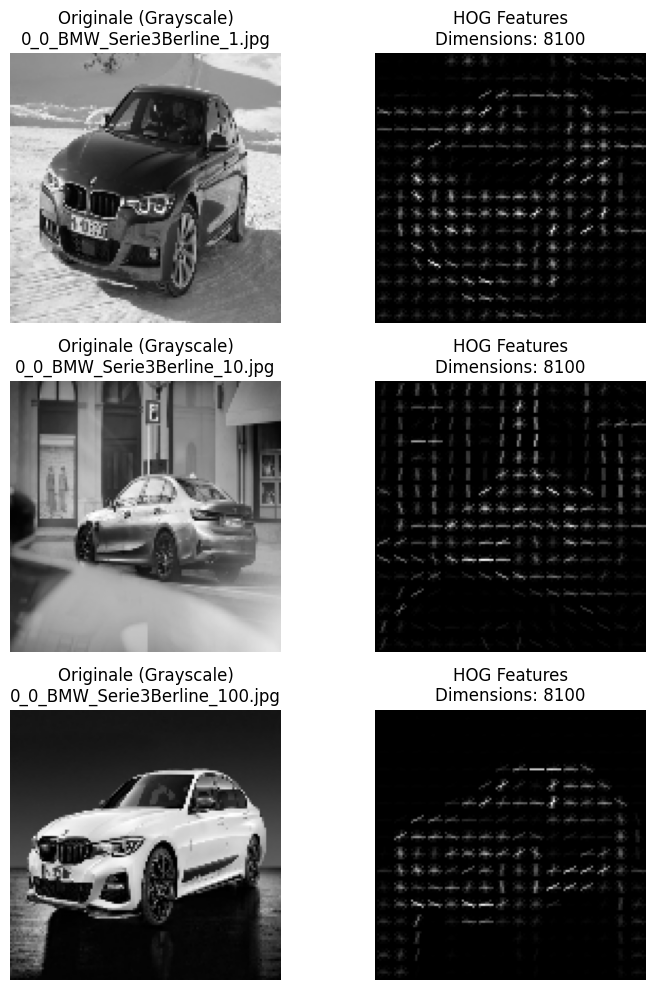

In [2]:
import os
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.metrics.pairwise import cosine_similarity

DATA_DIR = "../data/raw/Cars"
all_images = [f for f in os.listdir(DATA_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]

def extract_hog_features(img_path, target_size=(128, 128), visualize=False):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    
    img_resized = cv2.resize(img, target_size)
    
    if visualize:
        features, hog_image = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                                  cells_per_block=(2, 2), visualize=True)
        return features, hog_image, img_resized
    else:
        features = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), visualize=False)
        return features

fig, axes = plt.subplots(3, 2, figsize=(8, 10))
for i in range(3):
    img_path = os.path.join(DATA_DIR, all_images[i])
    features, hog_img, img_res = extract_hog_features(img_path, visualize=True)
    
    axes[i, 0].imshow(img_res, cmap='gray')
    axes[i, 0].set_title(f"Originale (Grayscale)\n{all_images[i]}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(hog_img, cmap='gray')
    axes[i, 1].set_title(f"HOG Features\nDimensions: {features.shape[0]}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [3]:
print(f"Début de l'indexation HOG pour {len(all_images)} images...")

db_features = []
db_paths = []
db_classes = []

start_index_time = time.time()

for img_name in all_images:
    img_path = os.path.join(DATA_DIR, img_name)
    feat = extract_hog_features(img_path)
    
    if feat is not None:
        db_features.append(feat)
        db_paths.append(img_path)
        
        parts = img_name.split('_')
        db_classes.append(f"{parts[0]}_{parts[1]}")

end_index_time = time.time()

db_features = np.array(db_features)
db_paths = np.array(db_paths)
db_classes = np.array(db_classes)

indexing_time = end_index_time - start_index_time
descriptor_size_mb = db_features.nbytes / (1024 * 1024)

print("-" * 40)
print(f"Temps total d'indexation : {indexing_time:.2f} secondes")
print(f"Taille de la base de descripteurs : {descriptor_size_mb:.2f} MB")
print(f"Dimension d'un descripteur HOG : {db_features.shape[1]}")
print("-" * 40)

Début de l'indexation HOG pour 10000 images...
----------------------------------------
Temps total d'indexation : 116.52 secondes
Taille de la base de descripteurs : 617.98 MB
Dimension d'un descripteur HOG : 8100
----------------------------------------


In [4]:
def calculate_metrics_at_k(retrieved_classes, true_class, total_relevant_in_db, k):
    retrieved_k = retrieved_classes[:k]
    
    relevant_retrieved = sum(1 for c in retrieved_k if c == true_class)
    
    precision_at_k = relevant_retrieved / k
    recall_at_k = relevant_retrieved / total_relevant_in_db if total_relevant_in_db > 0 else 0
    
    ap = 0.0
    relevant_count = 0
    for i, c in enumerate(retrieved_k):
        if c == true_class:
            relevant_count += 1
            ap += relevant_count / (i + 1)
            
    ap_at_k = ap / min(total_relevant_in_db, k) if total_relevant_in_db > 0 else 0
    
    return precision_at_k, recall_at_k, ap_at_k

In [5]:
QUERIES_GROUP_5 = [
    "0_1_BMW_X3_207.jpg",
    "0_0_BMW_Serie3Berline_74.jpg",
    "0_2_BMW_i8_299.jpg",
    "2_0_Volkswagen_Touareg_2822.jpg",
    "2_4_Volkswagen_Polo_3463.jpg",
    "2_9_Volkswagen_T-Roc_4209.jpg",
    "4_2_Opel_vivarofourgon_5999.jpg",
    "4_4_Opel_Insignatourer_6353.jpg",
    "4_9_Opel_zafiralife_6887.jpg",
    "6_0_Hyundai_Nexo_8282.jpg",
    "6_3_Hyundai_i10_8837.jpg",
    "6_5_Hyundai_i30_9125.jpg",
    "8_1_Ford_Puma_11276.jpg",
    "8_5_Ford_Explorer_11897.jpg",
    "8_6_Ford_Focus_11951.jpg"
]

if len(QUERIES_GROUP_5) < 15:
    print("Liste de requêtes incomplète, utilisation de 15 images aléatoires pour le test.")
    QUERIES_GROUP_5 = all_images[:15]

metrics_50 = {'P': [], 'R': [], 'AP': []}
metrics_100 = {'P': [], 'R': [], 'AP': []}
search_times = []

print(f"{'Requête':<25} | {'mAP@50':<8} | {'mAP@100':<8}")
print("-" * 45)

for q_img in QUERIES_GROUP_5:
    q_path = os.path.join(DATA_DIR, q_img)
    parts = q_img.split('_')
    q_class = f"{parts[0]}_{parts[1]}"
    
    total_relevant = sum(1 for c in db_classes if c == q_class)
    
    start_search = time.time()
    q_feat = extract_hog_features(q_path)
    if q_feat is None: continue
        
    similarities = cosine_similarity(q_feat.reshape(1, -1), db_features)[0]
    
    top_indices = np.argsort(similarities)[::-1]
    end_search = time.time()
    
    search_times.append(end_search - start_search)
    
    retrieved_classes = [db_classes[idx] for idx in top_indices if db_paths[idx] != q_path]
    
    p50, r50, ap50 = calculate_metrics_at_k(retrieved_classes, q_class, total_relevant, 50)
    metrics_50['P'].append(p50); metrics_50['R'].append(r50); metrics_50['AP'].append(ap50)
    
    p100, r100, ap100 = calculate_metrics_at_k(retrieved_classes, q_class, total_relevant, 100)
    metrics_100['P'].append(p100); metrics_100['R'].append(r100); metrics_100['AP'].append(ap100)
    
    print(f"{q_img[:20]:<25} | {ap50*100:5.1f}%   | {ap100*100:5.1f}%")

print("\n" + "=" * 40)
print("BILAN FINAL - DESCRIPTEUR HOG")
print("=" * 40)
print(f"Temps de recherche moyen  : {np.mean(search_times)*1000:.2f} ms / image")
print("\n--- Performances @50 ---")
print(f"Precision moyenne (mP)    : {np.mean(metrics_50['P'])*100:.2f} %")
print(f"Recall moyen (mR)         : {np.mean(metrics_50['R'])*100:.2f} %")
print(f"Mean Avg Precision (mAP)  : {np.mean(metrics_50['AP'])*100:.2f} %")

print("\n--- Performances @100 ---")
print(f"Precision moyenne (mP)    : {np.mean(metrics_100['P'])*100:.2f} %")
print(f"Recall moyen (mR)         : {np.mean(metrics_100['R'])*100:.2f} %")
print(f"Mean Avg Precision (mAP)  : {np.mean(metrics_100['AP'])*100:.2f} %")

Requête                   | mAP@50   | mAP@100 
---------------------------------------------
0_1_BMW_X3_207.jpg        |   0.5%   |   0.3%
0_0_BMW_Serie3Berlin      |   2.0%   |   1.0%
0_2_BMW_i8_299.jpg        |   0.3%   |   0.2%
2_0_Volkswagen_Touar      |   0.1%   |   0.0%
2_4_Volkswagen_Polo_      |   0.0%   |   0.0%
2_9_Volkswagen_T-Roc      |   0.2%   |   0.1%
4_2_Opel_vivarofourg      |   2.0%   |   1.0%
4_4_Opel_Insignatour      |   0.0%   |   0.0%
4_9_Opel_zafiralife_      |   0.0%   |   0.0%
6_0_Hyundai_Nexo_828      |   3.9%   |   2.0%
6_3_Hyundai_i10_8837      |   0.4%   |   0.2%
6_5_Hyundai_i30_9125      |   0.0%   |   0.0%
8_1_Ford_Puma_11276.      |   0.0%   |   0.1%
8_5_Ford_Explorer_11      |   2.0%   |   1.0%
8_6_Ford_Focus_11951      |   0.0%   |   0.0%

BILAN FINAL - DESCRIPTEUR HOG
Temps de recherche moyen  : 337.49 ms / image

--- Performances @50 ---
Precision moyenne (mP)    : 2.00 %
Recall moyen (mR)         : 0.86 %
Mean Avg Precision (mAP)  : 0.76 %

--- Per